In [1]:
import os
import logging

import csv
import numpy as np
import xarray as xr
import pandas as pd
import datetime

import matplotlib.pyplot as plt
import cmocean as cmo

from oceanpy import retrieve_attrs
import neutral_density as nd 

In [2]:
global_attrs = {
    "title": "Three EM-APEX floats seeded in the ACC's Polar Front downstream of the South East Indian Ridge",
    "institution": "Institute for Marine and Antarctic Studies, University of Tasmania",
    "references": "https://github.com/southern-ocean-dynamics/ema-seir-pf",
    "comment": (
        "The EM-APEX floats were funded by the Australian Research Council "
        "Discovery Project 24, \"Antarctica's leaky defence to poleward heat "
        "transport\", and deployed in the middle of a CPIES array from the "
        "Southern Ocean Fronts and Eddies (SOFE) project, a collaboration "
        "with the University of Rhode Island funded by NSF (USA) and the "
        "Korea Polar Research Institute (KOPRI, South Korea)."
    ),
    "Conventions": "CF-1.6",
    "instrument": "seabird_ctd_41cp sensor, apluw_ema sensor, iridium9523 device, gps15xh device",
    "featureType": "trajectoryProfile",
}

In [3]:
cruise_id = 'sofe'
float_ids = ['f10761', 'f10762', 'f10763']

In [ ]:
repodir = os.path.dirname(os.getcwd())
print('Repository: ', repodir)
datadir = os.path.join(repodir, 'data')
figsdir = os.path.join(repodir, 'figs')
outdir = os.path.join(repodir, 'output')

savefig = False
savenc = False
if savenc:
    savedir = os.path.join(outdir, 'ctd')
    if not os.path.exists(savedir):
        os.makedirs(savedir)

Repository:  /home/jjmeijer/Repos/ema-seir-pf


In [5]:
filedirs = {}
for float_id in float_ids:
    filedirs[float_id] = {
        'dec': os.path.join(datadir, cruise_id, float_id, 'proc', 'dec'),
        'vel': os.path.join(datadir, cruise_id, float_id, 'proc', 'vel')
    }

## Read CSV files

In [6]:
# read all science files
ctd_descent, ctd_ascent = {}, {}
gps_surface, gps_ascent, gps_descent = {}, {}, {}

# float_id = float_ids[0]
for float_id in float_ids:

    files = [os.path.join(filedirs[float_id]['dec'], file) for file in sorted(os.listdir(filedirs[float_id]['dec'])) if file.endswith('science_log.csv')]

    # for filename in files:
    #     read_science_csv(filename)
    
    # def read_science_csv():

    ctd_descent[float_id], ctd_ascent[float_id] = {}, {}
    gps_surface[float_id], gps_ascent[float_id], gps_descent[float_id] = {}, {}, {}

    for filename in files:
        profile_no = os.path.basename(filename).split('.')[1]
        # print(profile_no, filename)
    
        # setup surface data structure
        gps_surface[float_id][profile_no] = {'TIMESTAMP': [], 'LAT': [], 'LON': [], 'NSAT': []}
        
        # setup descent data structures
        ctd_descent[float_id][profile_no] = {'time': np.array([]), 'p': np.array([]), 'T': np.array([]), 'S': np.array([])}
        gps_descent[float_id][profile_no] = {'TIMESTAMP': [], 'LAT': [], 'LON': [], 'NSAT': []}
    
        # setup ascent data structures
        ctd_ascent[float_id][profile_no] = {'time': np.array([]), 'p': np.array([]), 'T': np.array([]), 'S': np.array([])}
        gps_ascent[float_id][profile_no] = {'TIMESTAMP': [], 'LAT': [], 'LON': [], 'NSAT': []}
    
        # assume starting with a descent until the ascent message is found
        process_as_ascent_data = False
        found_descent_start = False
        found_ascent_start = False
    
        with open(filename, newline='') as csvfile:
        
            reader = csv.DictReader(csvfile, fieldnames=['ID', 'TIMESTAMP'], restkey='DATA')
            for row in reader:
    
                # pick up mission status
                if row['ID'] == 'Message':
                    if row['DATA'][0] == 'ASCENT':
                        process_as_ascent_data = True
                        found_ascent_start = True
                    elif row['DATA'][0] == 'Park Descent Mission':
                        found_descent_start = True
    
                # process CTD PTS data
                elif row['ID'] == 'CTD_PTS' or row['ID'] == "LGR_PTSCI":
    
                    timestamp = datetime.datetime.strptime(row['TIMESTAMP'],'%Y%m%dT%H%M%S')
                    pressure = float(row['DATA'][0])
                    temperature = float(row['DATA'][1])
                    salinity = float(row['DATA'][2])
                    
                    if process_as_ascent_data:
                        ctd_ascent[float_id][profile_no]['time'] = np.append(ctd_ascent[float_id][profile_no]['time'], timestamp)
                        ctd_ascent[float_id][profile_no]['p'] = np.append(ctd_ascent[float_id][profile_no]['p'], pressure)
                        ctd_ascent[float_id][profile_no]['T'] = np.append(ctd_ascent[float_id][profile_no]['T'], temperature)
                        ctd_ascent[float_id][profile_no]['S'] = np.append(ctd_ascent[float_id][profile_no]['S'], salinity)
                    else:
                        ctd_descent[float_id][profile_no]['time'] = np.append(ctd_descent[float_id][profile_no]['time'], timestamp)
                        ctd_descent[float_id][profile_no]['p'] = np.append(ctd_descent[float_id][profile_no]['p'], pressure)
                        ctd_descent[float_id][profile_no]['T'] = np.append(ctd_descent[float_id][profile_no]['T'], temperature)
                        ctd_descent[float_id][profile_no]['S'] = np.append(ctd_descent[float_id][profile_no]['S'], salinity)
                        
                # process GPS data
                elif row['ID'] == 'GPS':
                    
                    if process_as_ascent_data:
                        gps_data_dict = gps_ascent
                    else:
                        gps_data_dict = gps_descent
    
                    timestamp = datetime.datetime.strptime(row['TIMESTAMP'],'%Y%m%dT%H%M%S')
                    lat = float(row['DATA'][0])
                    lon = float(row['DATA'][1])
                    nsat = float(row['DATA'][2])
                    
                    # skip bad gps values
                    if np.isfinite(lat) and np.isfinite(lon) and np.isfinite(nsat):
                        gps_data_dict[float_id][profile_no]['TIMESTAMP'] = np.append(gps_data_dict[float_id][profile_no]['TIMESTAMP'], timestamp)
                        gps_data_dict[float_id][profile_no]['LAT'] = np.append(gps_data_dict[float_id][profile_no]['LAT'], lat)
                        gps_data_dict[float_id][profile_no]['LON'] = np.append(gps_data_dict[float_id][profile_no]['LON'], lon )
                        gps_data_dict[float_id][profile_no]['NSAT'] = np.append(gps_data_dict[float_id][profile_no]['NSAT'], nsat)
    
        # end of collecting data, begin processing
        if len(ctd_descent[float_id][profile_no]['time']) == 0 or len(ctd_descent[float_id][profile_no]['p']) == 0 or len(ctd_descent[float_id][profile_no]['T']) == 0 or len(ctd_descent[float_id][profile_no]['S']) == 0:
            ctd_descent[float_id].pop(profile_no)
            logging.error("missing CTD data in descent profile %d, removed profile %s from dict" % (int(profile_no), profile_no))
            continue
        if len(ctd_ascent[float_id][profile_no]['time']) == 0 or len(ctd_ascent[float_id][profile_no]['p']) == 0 or len(ctd_ascent[float_id][profile_no]['T']) == 0 or len(ctd_ascent[float_id][profile_no]['S']) == 0:
            ctd_ascent[float_id].pop(profile_no)
            logging.error("missing CTD data in ascent profile %d, removed profile %s from dict" % (int(profile_no), profile_no))
            continue
        if len(gps_descent[float_id][profile_no]['TIMESTAMP']) == 0:
            logging.error("no descent GPS data found in profile %d" % int(profile_no))
            continue
        elif len(gps_ascent[float_id][profile_no]['TIMESTAMP']) == 0:
            logging.error("no ascent GPS data found in profile %d" % int(profile_no))
            continue
        elif not found_descent_start:
            logging.error("descent not found in science log in profile %d" % int(profile_no))
            continue
        elif not found_ascent_start:
            logging.error("ascent not found in science log in profile %d" % int(profile_no))
            continue
    
        # save the initial gps at start of previous surfacing for surface trift
        gps_surface[float_id][profile_no]['TIMESTAMP'] = gps_descent[float_id][profile_no]['TIMESTAMP'][0]
        gps_surface[float_id][profile_no]['LAT'] = gps_descent[float_id][profile_no]['LAT'][0]
        gps_surface[float_id][profile_no]['LON'] = gps_descent[float_id][profile_no]['LON'][0]
        gps_surface[float_id][profile_no]['NSAT'] = gps_descent[float_id][profile_no]['NSAT'][0]


ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in ascent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in ascent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in descent profile 0, removed profile 000 from dict
ERROR:root:missing CTD data in ascent profile 0, removed profile 000 from dict


In [7]:
for float_id in float_ids:

    # make a set of stations, each station has a descent and an ascent profile
    stations = np.unique([int(pf_no) for pf_no in list(ctd_descent[float_id].keys()) + list(ctd_ascent[float_id].keys())])
    stations = np.array([x for x in stations for _ in range(2)])
    
    # define dimensions of dataset/ arrays
    profiles = np.array([ipf for ipf in range(len(stations))])
    nlevels = max(max([(len(d_values['time']), len(a_values['time'])) 
                       for d_values, a_values in zip(ctd_descent[float_id].values(), ctd_ascent[float_id].values())]))
    levels = np.linspace(0, nlevels, nlevels+1)
    
    # initialise empty masked arrays
    shape = (len(profiles), len(levels))
    ctd_array = {
        # 'time': np.ma.masked_all(shape, dtype='datetime64[s]'),
        'p': np.ma.masked_all(shape),
        'T': np.ma.masked_all(shape),
        'S': np.ma.masked_all(shape),
    }
    gps_array = {
        'time': np.ma.masked_all(len(profiles), dtype=object),
        'lon': np.ma.masked_all(len(profiles)),
        'lat': np.ma.masked_all(len(profiles)),
        'cycle': np.ma.masked_all(len(profiles), dtype=str),
    }

    # make square arrays from data in dictionary
    i_descent, i_ascent = 0, 1
    for (pf_no_desc, pf_data_desc), (pf_no_asc, pf_data_asc) in zip(ctd_descent[float_id].items(), ctd_ascent[float_id].items()):
        
        # processing descent ctd data
        # ctd_array['time'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['time']
        ctd_array['p'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['p']
        ctd_array['T'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['T']
        ctd_array['S'][i_descent, :len(pf_data_desc['time'])] = pf_data_desc['S']
    
        # processing ascent ctd data
        # ctd_array['time'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['time'])
        ctd_array['p'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['p'])
        ctd_array['T'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['T'])
        ctd_array['S'][i_ascent, :len(pf_data_asc['time'])] = np.flip(pf_data_asc['S'])
        
        # processing gps data
        try:
            gps_array['lon'][i_descent] = gps_descent[float_id][pf_no_desc]['LON'][-1]
            gps_array['lat'][i_descent] = gps_descent[float_id][pf_no_desc]['LAT'][-1]
            gps_array['time'][i_descent] = gps_descent[float_id][pf_no_desc]['TIMESTAMP'][-1]
            gps_array['cycle'][i_descent] = 'D'
        except IndexError:
            print('no GPS coordinates in descent profile %s' %pf_no_desc)
            # processing gps data
        try:
            gps_array['lon'][i_ascent] = gps_ascent[float_id][pf_no_asc]['LON'][0]
            gps_array['lat'][i_ascent] = gps_ascent[float_id][pf_no_asc]['LAT'][0]
            gps_array['time'][i_ascent] = gps_ascent[float_id][pf_no_asc]['TIMESTAMP'][0]
            gps_array['cycle'][i_ascent] = 'A'
        except IndexError:
            print('no GPS coordinates in ascent profile %s' %pf_no_asc)
        
        i_descent += 2
        i_ascent += 2
    
    # create dimensions and coordinates of Dataset
    finite = ~gps_array['time'].mask | ~gps_array['lon'].mask | ~gps_array['lat'].mask
    coords = dict(
        station=('profile', stations[finite]),
        vertical=('level', levels),
        time=('profile', gps_array['time'][finite]),
        longitude=('profile', gps_array['lon'][finite]),
        latitude=('profile', gps_array['lat'][finite]),
        cycle=('profile', gps_array['cycle'][finite])
    )
    
    # link CTD data to dimensions and coordinates
    data_vars = dict(
        # time=(['profile', 'level'], ctd_array['time']),
        p=(['profile', 'level'], ctd_array['p'][finite]),
        T=(['profile', 'level'], ctd_array['T'][finite]),
        S=(['profile', 'level'], ctd_array['S'][finite]),
    )
    
    # store in xarray Dataset
    ctd = xr.Dataset(data_vars=data_vars, coords=coords)
    
    # apply global attributes / metadata
    global_attrs["source"] = f"EM-APEX float: {float_id}"
    global_attrs["history"] = "Created " + pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")    
    ctd.attrs.update(global_attrs)

    # apply variable attributes / metadata
    variables = list(ctd.data_vars) + ['time', 'latitude', 'longitude']
    attrs_dict = retrieve_attrs(variables)
    for var, attrs in attrs_dict.items():
        if var in ctd.variables:
            ctd[var].attrs.update(attrs)
            # print(var, attrs)
        else:
            print(f"Warning: '{var}' not found in dataset — skipping")

    # save to netcdf file
    if savenc:
        ctd.to_netcdf(os.path.join(savedir, 'ema-%s-ctd-raw.nc' %float_id))
    ctd.close()

In [8]:
for float_id in float_ids:

    filename = os.path.join(os.path.join(outdir, 'ctd', 'ema-%s-ctd-raw.nc' %float_id))
    ctd = xr.open_dataset(filename)
    
    # make pressure coordinate
    dp = 2
    max_pressure = max([np.append(d_values['p'], a_values['p']).max()
                       for d_values, a_values in zip(ctd_descent[float_id].values(), ctd_ascent[float_id].values())])
    max_pressure = np.ceil(max_pressure / 2.) * 2
    pressure_coord = np.linspace(0, max_pressure, int(max_pressure / dp) + 1)
    
    def interp_profile(var, press):
        var_interp = np.interp(pressure_coord, press, var)
        finite_vals = var_interp[np.isfinite(var_interp)]
        if finite_vals.size == 0 or np.all(finite_vals == finite_vals[0]):
            return np.full_like(pressure_coord, np.nan, dtype=var.dtype)
        return np.interp(pressure_coord, press, var)

    def _gamman(ctd, S_interp, T_interp, pressure_coord):
        valid = np.isfinite(S_interp) & np.isfinite(T_interp)
        gn = np.full_like(pressure_coord, np.nan, dtype=float)
        if valid.any():
            gn[valid] = nd.gamma_n(
                S_interp[valid], T_interp[valid], pressure_coord, 
                float(ctd.longitude), float(ctd.latitude))[0]
        return gn
    
    temperature_interp = xr.apply_ufunc(
        interp_profile,
        ctd['T'],
        ctd['p'],
        input_core_dims=[['level'], ['level']],
        output_core_dims=[['pressure']],
        vectorize=True,
        dask='parallelized' if ctd['T'].chunks else False,
        output_dtypes=[ctd['T'].dtype]
    )
    
    salinity_interp = xr.apply_ufunc(
        interp_profile,
        ctd['S'],
        ctd['p'],
        input_core_dims=[['level'], ['level']],
        output_core_dims=[['pressure']],
        vectorize=True,
        dask='parallelized' if ctd['S'].chunks else False,
        output_dtypes=[ctd['T'].dtype]
    )
    
    # create dimensions and coordinates of Dataset
    coords = dict(
        time=('profile', ctd.time.values),
        station=('profile', ctd.station.values),
        pressure=('pressure', pressure_coord),
        longitude=('profile', ctd.longitude.values),
        latitude=('profile', ctd.latitude.values),
        cycle=('profile', ctd.cycle.values),

    )
    
    gamman = np.stack([
        _gamman(ctd.isel(profile=i), salinity_interp[i,:].values, 
        temperature_interp[i,:], pressure_coord) 
        for i in range(ctd.sizes['profile'])])

    # link CTD data to dimensions and coordinates
    data_vars = dict(
        T=(['profile', 'pressure'], temperature_interp.values),
        S=(['profile', 'pressure'], salinity_interp.values),
        gamman=(['profile', 'pressure'], gamman),
    )
    
    # store in xarray Dataset
    ctd_interp = xr.Dataset(data_vars=data_vars, coords=coords)

    # apply global attributes / metadata
    global_attrs["source"] = f"EM-APEX float: {float_id}"
    global_attrs["history"] = "Created " + pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")    
    ctd_interp.attrs.update(global_attrs)

    # apply variable attributes / metadata
    variables = list(ctd_interp.data_vars) + ['time', 'latitude', 'longitude', 'pressure']
    attrs_dict = retrieve_attrs(variables)
    for var, attrs in attrs_dict.items():
        if var in ctd_interp.variables:
            ctd_interp[var].attrs.update(attrs)
            # print(var, attrs)
        else:
            print(f"Warning: '{var}' not found in dataset — skipping")
    
    if savenc:
        ctd_interp.to_netcdf(os.path.join(savedir, 'ema-%s-ctd-pgrid.nc' %float_id))
    ctd_interp.close()

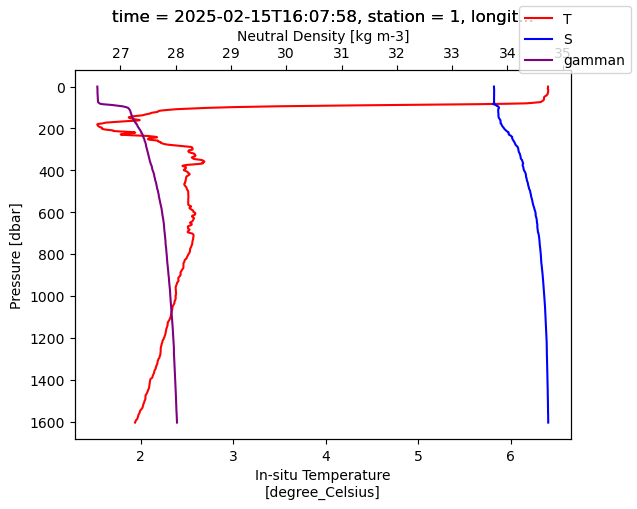

In [9]:
profile=2

fig, ax =plt.subplots()

# temperature 
# ax.plot(ctd.isel(profile=profile).T, ctd.isel(profile=profile).pressure, label='obs')
ctd_interp.isel(profile=profile).T.plot(ax=ax, y='pressure', label='T', color='red')

# salinity
ax2 = ax.twiny()
# ax2.plot(ctd.isel(profile=profile).S, ctd.isel(profile=profile).pressure, label='obs')
ctd_interp.isel(profile=profile).S.plot(ax=ax2, y='pressure', label='S', color='blue')

ctd_interp.isel(profile=profile).gamman.plot(ax=ax2, y='pressure', label='gamman', color='purple')

ax.invert_yaxis()
fig.legend()

start: 2025-02-15T16:01:51.000000000
end: 2025-03-26T11:17:03.000000000
start: 2025-02-15T16:21:03.000000000
end: 2025-03-26T09:25:48.000000000
start: 2025-02-15T15:49:55.000000000
end: 2025-03-26T18:20:21.000000000


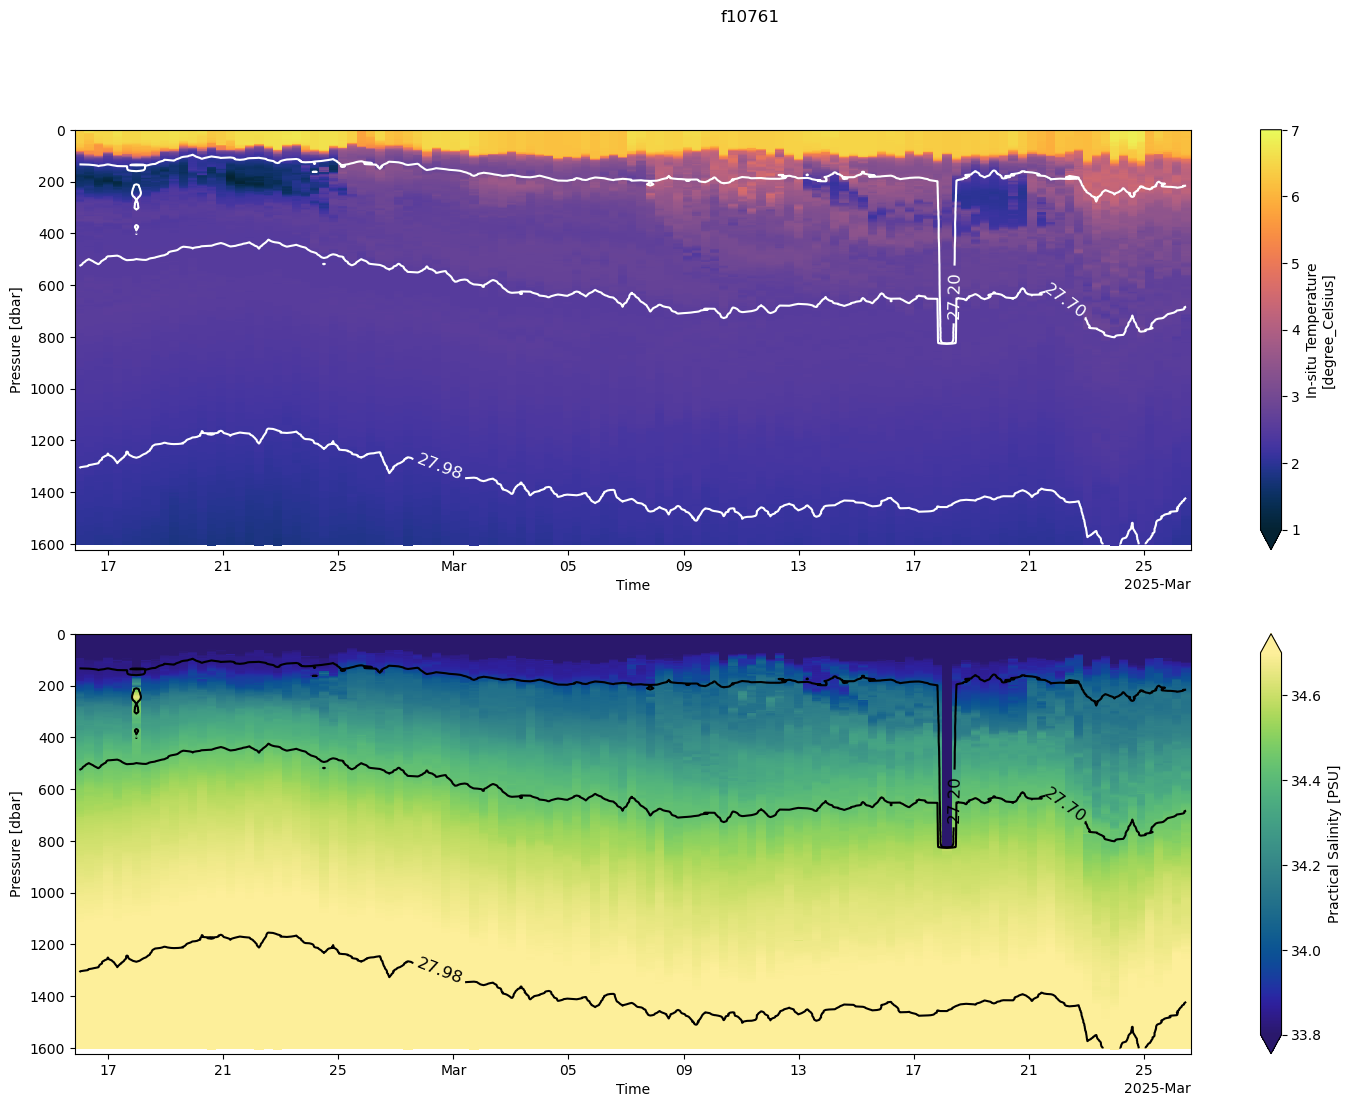

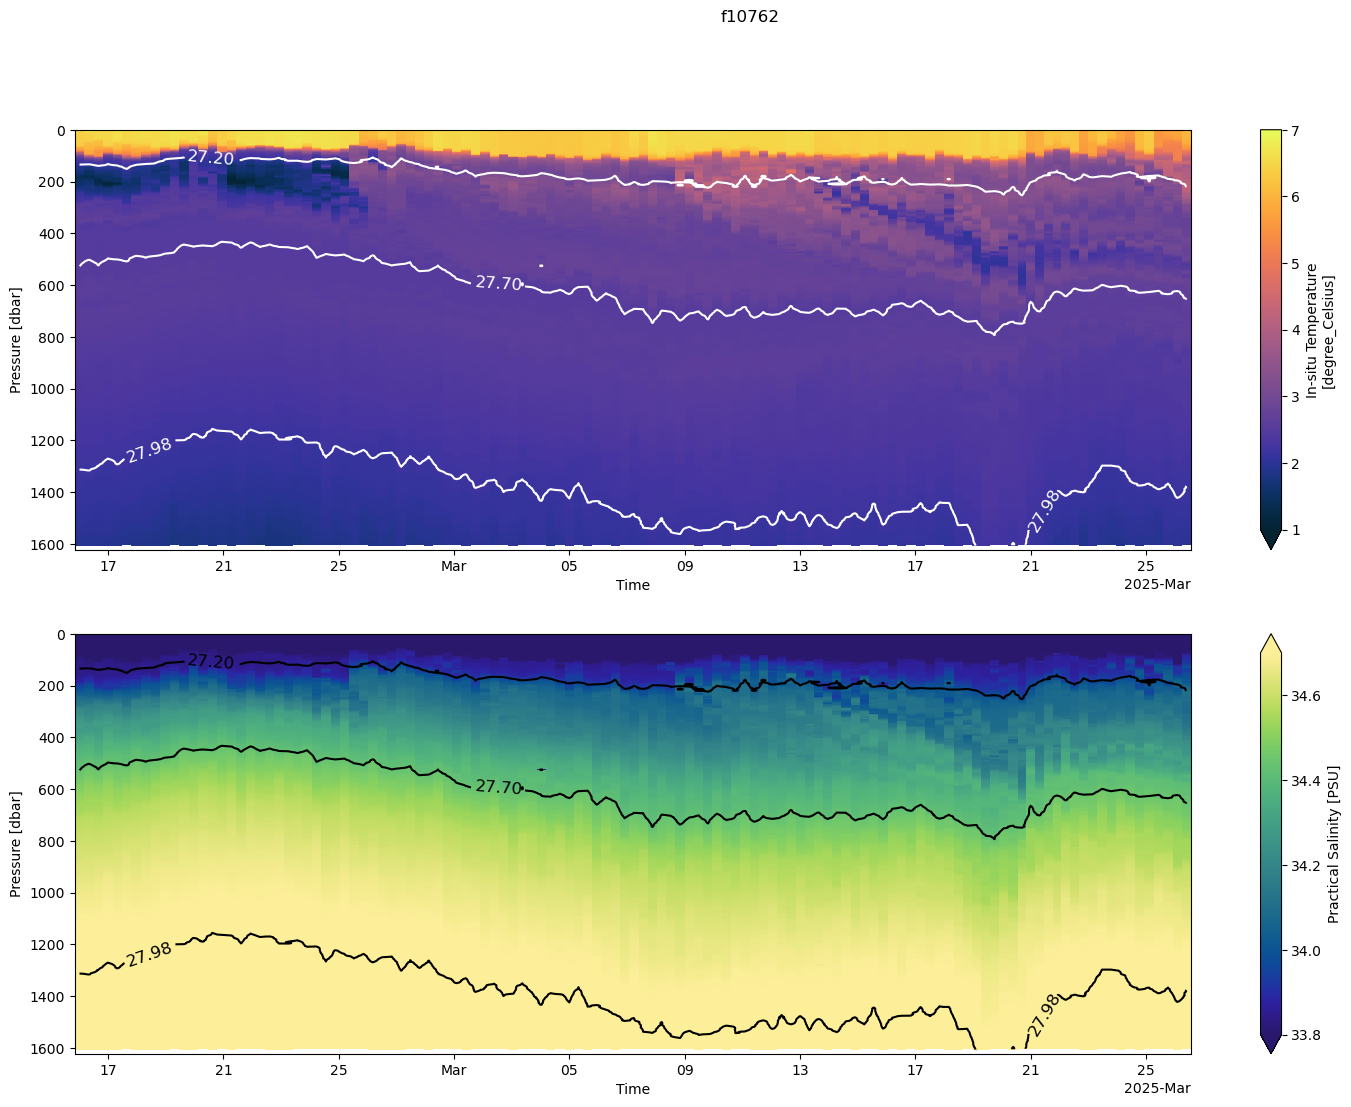

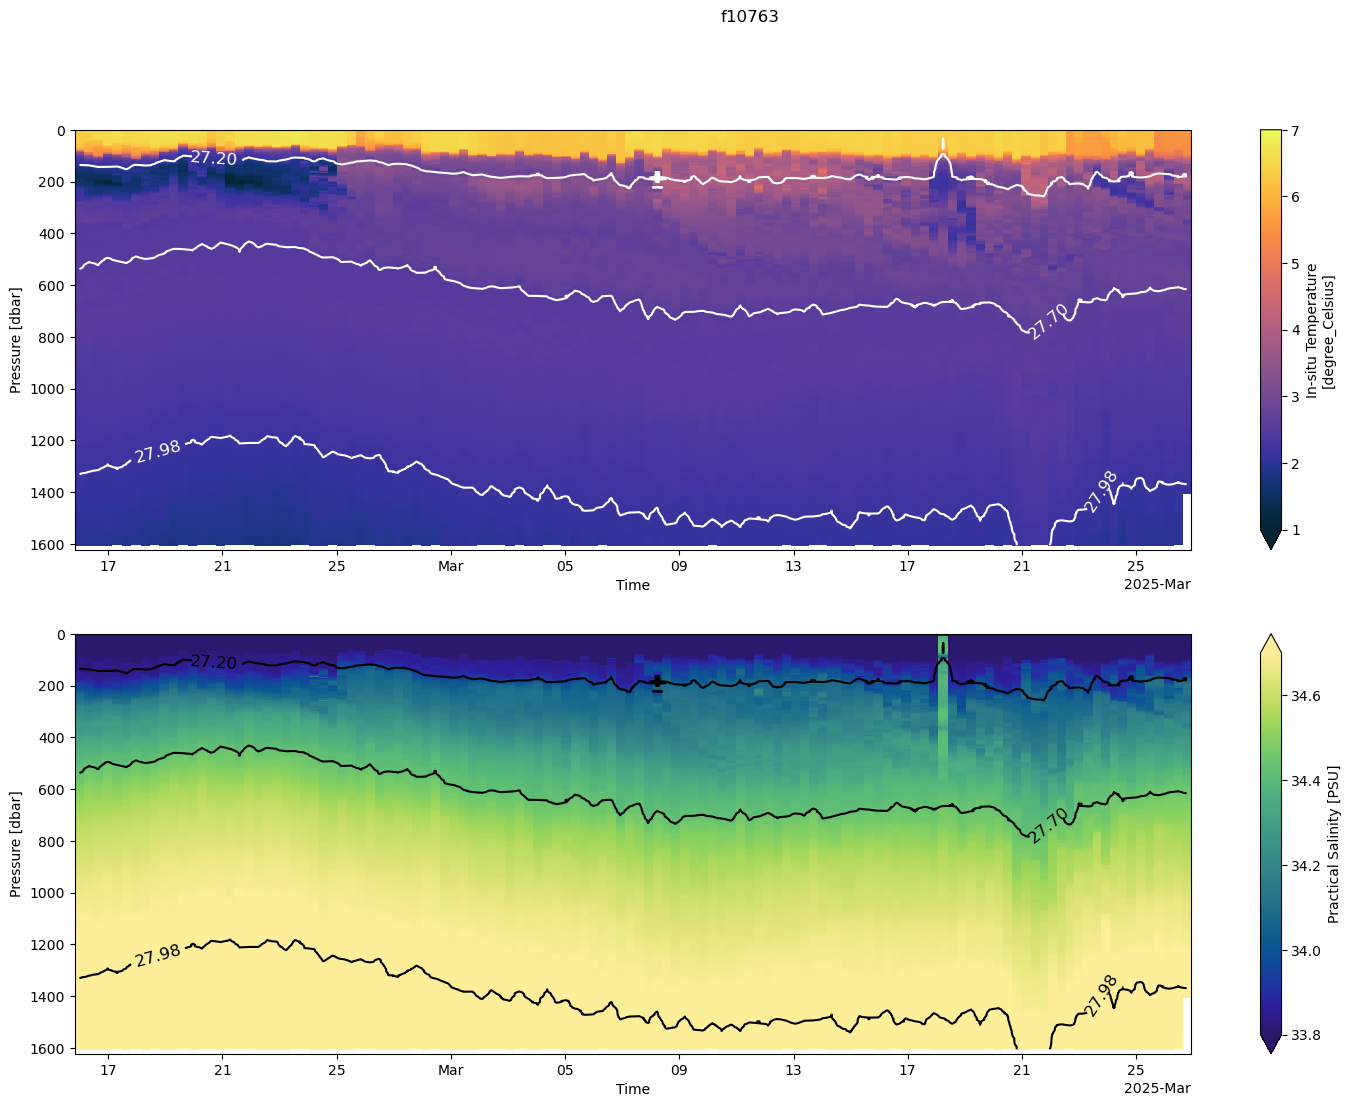

In [10]:
gamman_levels = [27.2, 27.7, 27.98]
for float_id in float_ids:

    filename = os.path.join(outdir, 'ctd', 'ema-%s-ctd-pgrid.nc' %float_id)
    ctd = xr.open_dataset(filename)

    ctd_rapid = ctd.isel(profile=slice(0,240))

    print('start: %s' %ctd.time[0].values)
    print('end: %s' %ctd_rapid.time[-1].values)

    fig, ax = plt.subplots(nrows=2, figsize=(18,12))
    
    ctd_rapid.sel(profile=ctd_rapid.cycle == "A").T.plot(ax=ax[0], x='time', cmap=cmo.cm.thermal, vmin=1, vmax=7)
    cont = ctd_rapid.sel(profile=ctd_rapid.cycle == "A").gamman.plot.contour(ax=ax[0], x='time', levels=gamman_levels, colors='w')
    ax[0].invert_yaxis()
    cont.clabel(fontsize=12)
    
    ctd_rapid.sel(profile=ctd_rapid.cycle == "A").S.plot(ax=ax[1], x='time', vmin=33.8, vmax=34.7, cmap=cmo.cm.haline)
    cont = ctd_rapid.sel(profile=ctd_rapid.cycle == "A").gamman.plot.contour(ax=ax[1], x='time', levels=gamman_levels, colors='k')
    ax[1].invert_yaxis()
    cont.clabel(fontsize=12)

    fig.suptitle(float_id)

    if savefig:
        fig.savefig(os.path.join(figsdir, '03_temp-sal_on-pgrid_%s.png' %float_id))